In [149]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [150]:
df = pd.read_csv("mnist_train.csv",header=None)
df_test = pd.read_csv("mnist_test.csv",header=None)

In [151]:
df.rename(columns={0: "label"}, inplace=True)
df_test.rename(columns={0: "label"}, inplace=True)

In [152]:
df

,label,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [153]:
df.shape

(60000, 785)

In [154]:
df.columns

Index(['label',       1,       2,       3,       4,       5,       6,       7,
             8,       9,
       ...
           775,     776,     777,     778,     779,     780,     781,     782,
           783,     784],
      dtype='object', length=785)

In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 784
dtypes: int64(785)
memory usage: 359.3 MB


In [156]:
df.isnull().sum()

label    0
1        0
2        0
3        0
4        0
        ..
780      0
781      0
782      0
783      0
784      0
Length: 785, dtype: int64

In [157]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values

X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [158]:
X_train=X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

In [159]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [160]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [161]:
Perceptron =Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [162]:
Perceptron.compile(optimizer="sgd", loss = 'categorical_crossentropy', metrics= ["accuracy"])

In [163]:
history_precp = Perceptron.fit(X_train_img, y_train_cat, epochs = 10, batch_size=32, validation_data=(X_test_img, y_test_cat),verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8173 - loss: 0.7756 - val_accuracy: 0.8795 - val_loss: 0.4824
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8801 - loss: 0.4569 - val_accuracy: 0.8953 - val_loss: 0.4019
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8909 - loss: 0.4036 - val_accuracy: 0.9020 - val_loss: 0.3682
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8967 - loss: 0.3768 - val_accuracy: 0.9062 - val_loss: 0.3491
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9007 - loss: 0.3600 - val_accuracy: 0.9080 - val_loss: 0.3366
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9038 - loss: 0.3480 - val_accuracy: 0.9097 - val_loss: 0.3272
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9061 - loss: 0.3390 - val_accuracy: 0.9122 - val_loss: 0.3207
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9083 - loss: 0.3318 - 

In [164]:
acc_precp = Perceptron.evaluate(X_test_img,y_test_cat, verbose=0)[1]

In [165]:
acc_precp

0.914900004863739

In [166]:
#ANN
ann =Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [167]:
ann.compile(optimizer="adam", loss ='categorical_crossentropy', metrics=["accuracy"])

In [168]:
history_ann = ann.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9305 - loss: 0.2354 - val_accuracy: 0.9603 - val_loss: 0.1249
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9688 - loss: 0.1011 - val_accuracy: 0.9689 - val_loss: 0.0963
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9781 - loss: 0.0703 - val_accuracy: 0.9729 - val_loss: 0.0877
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9832 - loss: 0.0535 - val_accuracy: 0.9732 - val_loss: 0.0873
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0434 - val_accuracy: 0.9768 - val_loss: 0.0735
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9883 - loss: 0.0351 - val_accuracy: 0.9786 - val_loss: 0.0737
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9759 - val_loss: 0.0883
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9918 - loss: 0.0251 - 

In [169]:
X_train_cnn =X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [171]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [172]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [173]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9336 - loss: 0.2179 - val_accuracy: 0.9846 - val_loss: 0.0453
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9761 - loss: 0.0820 - val_accuracy: 0.9882 - val_loss: 0.0359
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9823 - loss: 0.0601 - val_accuracy: 0.9895 - val_loss: 0.0330
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9854 - loss: 0.0476 - val_accuracy: 0.9912 - val_loss: 0.0286
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9870 - loss: 0.0430 - val_accuracy: 0.9918 - val_loss: 0.0254


In [175]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [176]:
acc_cnn

0.9918000102043152

In [179]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="val")
    plt.title(f"{title}Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

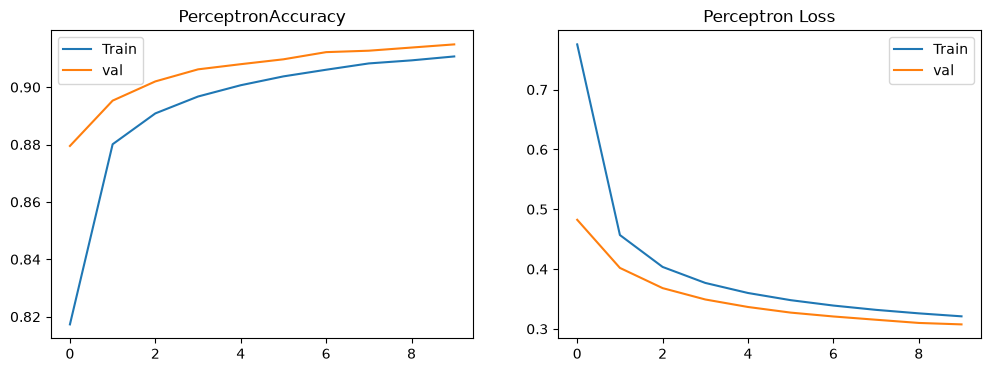

In [180]:
plot_training(history_precp,"Perceptron")

In [181]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    
    idxs = np.random.choice(len(X), n, replace=False)

    plt.figure(figsize=(15, 6))

    for i, idx in enumerate(idxs):

        # Original image
        plt.subplot(2, n, i + 1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")

        # Predictions
        preds = [
            np.argmax(
                model.predict(
                    X_cnn[idx].reshape(1, 28, 28, 1)
                    if name == "CNN"
                    else X[idx].reshape(1, 28, 28)
                ),
                axis=1
            )[0]
            for model, name in zip(models, model_names)
        ]

        plt.subplot(2, n, i + n + 1)
        plt.axis("off")
        plt.title(
            "\n".join(
                f"{name}: {p}"
                for name, p in zip(model_names, preds)
            )
        )

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


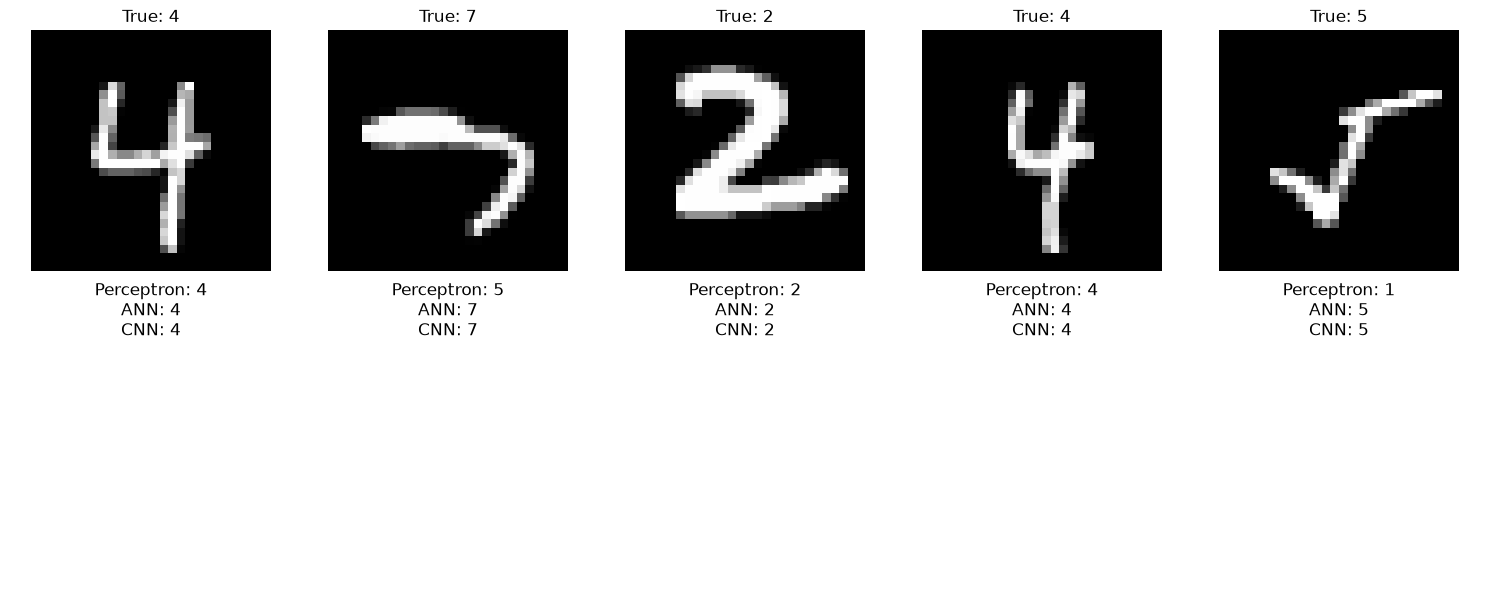

In [184]:
show_side_by_side(
    [Perceptron, ann, cnn],
    ["Perceptron", "ANN", "CNN"],
    X_train_img,
    X_train_cnn,
    y_train,
    n=5
)